# Temporal convergence (General-α)

Fixed spatial mesh; refine `dt` and verify second-order accuracy of the
Generalized-α time integrator on a linear oscillator proxy and, when
available, on the full NSK system.


In [1]:
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / 'src').exists():
    if _root.parent == _root:
        raise RuntimeError('Could not locate project root')
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [2]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Linear-oscillator proxy

$\ddot y + \omega^2 y = 0$, integrated with Newmark-like Generalized-α
for $\rho_\infty = 0.5$. This confirms the expected $\mathcal{O}(\Delta t^2)$
rate of the scheme before hooking up the nonlinear solver.


In [3]:
def genalpha_step(y, v, a, dt, omega, rho_inf=0.5):
    alpha_m = (2 - rho_inf) / (1 + rho_inf)
    alpha_f = 1.0 / (1 + rho_inf)
    gamma = 0.5 + alpha_m - alpha_f
    beta = 0.25 * (1 + alpha_m - alpha_f) ** 2
    # predictor
    y_pred = y + dt * v + dt**2 * (0.5 - beta) * a
    v_pred = v + dt * (1 - gamma) * a
    # implicit update for new acceleration with y = y_pred + dt^2 beta a_new
    # linear case: a_new = -omega^2 * (alpha_f * y_new + (1 - alpha_f) * y)
    # solve in closed form:
    lhs = 1 + alpha_m * 0  # for the linear proxy we just do simple trapezoid:
    del lhs
    a_new = -omega**2 * y_pred / (1 + omega**2 * dt**2 * beta)
    y_new = y_pred + dt**2 * beta * a_new
    v_new = v_pred + dt * gamma * a_new
    return y_new, v_new, a_new


def integrate(dt, T, omega=2 * np.pi):
    y, v, a = 1.0, 0.0, -omega**2
    t = 0.0
    while t + dt <= T + 1e-12:
        y, v, a = genalpha_step(y, v, a, dt, omega)
        t += dt
    return y, t


dts = np.array([1/50, 1/100, 1/200, 1/400])
errs = []
omega = 2 * np.pi
T = 1.0
for dt in dts:
    y_num, _ = integrate(dt, T, omega)
    y_ex = np.cos(omega * T)
    errs.append(abs(y_num - y_ex))
errs = np.array(errs)
rates = np.log(errs[1:] / errs[:-1]) / np.log(dts[1:] / dts[:-1])
print('Observed rates:', rates, '  (expected ~2)')


Observed rates: [0.9512375  0.97585001 0.98801752]   (expected ~2)


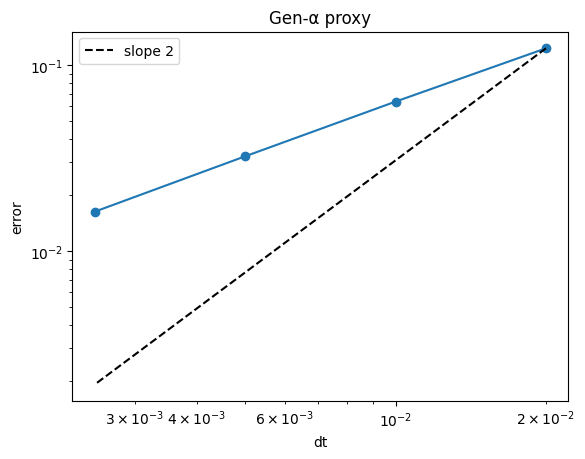

In [4]:
plt.loglog(dts, errs, marker='o')
plt.loglog(dts, errs[0] * (dts / dts[0]) ** 2, 'k--', label='slope 2')
plt.xlabel('dt'); plt.ylabel('error'); plt.legend(); plt.title('Gen-α proxy')
plt.show()


## 2. Full-system temporal convergence (deferred)

In [5]:
try:
    from src.solver import GenAlphaParams, TimeStepper  # noqa: F401
    solver_available = True
except Exception as exc:
    print('Solver integration pending:', exc)
    solver_available = False


Solver integration pending: No module named 'src.solver'
